# Classify Song genre from audio data

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA

In [2]:
# Reading train X's .csv file saved during Preprocessing
scaled_train_features = pd.read_csv('X_train.csv',header= None)
scaled_train_features.head()

,0,1,2,3,4,5,6,7
0,1.026792,-0.137114,-0.420266,1.048737,-0.603647,-0.709548,-0.877318,0.014663
1,-1.288978,1.338072,-0.330889,0.938967,-0.528823,-0.661191,-0.894361,-0.157071
2,-1.063741,0.965762,-0.961577,-0.144583,-0.863147,1.866813,1.822461,-0.333817
3,-1.293585,-1.298188,1.487448,0.926156,-0.522913,-0.624607,2.356353,0.762875
4,0.601626,-0.013549,-0.202983,-1.242428,1.264153,1.049873,1.039551,1.246512


In [3]:
scaled_train_features.columns = ['acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']

In [4]:
# Reading test X's .csv file saved during Preprocessing
scaled_test_features = pd.read_csv('X_test.csv',header= None)
scaled_test_features.head()

,0,1,2,3,4,5,6,7
0,1.305577,-0.534753,0.717014,0.567510,-0.069140,0.443746,1.774270,0.041892
1,1.479448,-0.967998,1.536417,0.269835,-0.015906,-0.416504,0.743674,-1.130441
2,-1.039831,1.173027,-0.602603,0.962462,-0.461786,-0.524242,1.096693,0.231371
3,-0.106700,-0.428815,0.853318,1.026501,0.007987,-0.620455,-0.707196,1.346695
4,-0.341679,0.727481,-0.783465,0.870499,-0.265444,-0.309937,1.330496,-0.490886


In [5]:
scaled_test_features.columns = ['acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']

Since we didn't find any particular strong correlations between our features during EDA, we can instead use a common approach to reduce the number of features called principal component analysis (PCA).

It is possible that the variance between genres can be explained by just a few features in the dataset. PCA rotates the data along the axis of highest variance, thus allowing us to determine the relative contribution of each feature of our data towards the variance between classes.

We can use scree-plots and cumulative explained ratio plots to find the number of components to use in further analyses.

## PCA

Text(0.5, 0, 'Principal Component #')

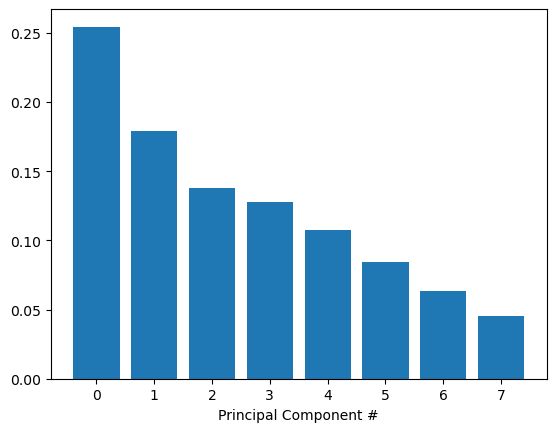

In [6]:
# Get our explained variance ratios from PCA using all features
pca = PCA()
pca.fit(scaled_train_features)
exp_variance = pca.explained_variance_ratio_

# plot the explained variance using a barplot
fig, ax = plt.subplots()
ax.bar(range(pca.n_components_), exp_variance)
ax.set_xlabel('Principal Component #')

Unfortunately, there does not appear to be a clear elbow in this scree plot, which means it is not straightforward to find the number of intrinsic dimensions using this method.

But all is not lost! Instead, we can also look at the cumulative explained variance plot to determine how many features are required to explain, say, about 85% of the variance (cutoffs are somewhat arbitrary here, and usually decided upon by 'rules of thumb'). Once we determine the appropriate number of components, we can perform PCA with that many components, ideally reducing the dimensionality of our data.

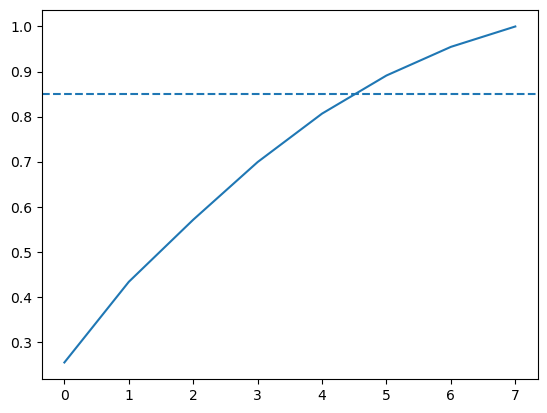

In [7]:
# Calculate the cumulative explained variance
cum_exp_variance = np.cumsum(exp_variance)

# Plot the cumulative explained variance and draw a dashed line at 0.85.
fig, ax = plt.subplots()
ax.plot(cum_exp_variance)
ax.axhline(y=0.85, linestyle='--')

We saw from the plot that 6 features (remember indexing starts at 0) can explain 85% of the variance!

Therefore, we can use 6 components to perform PCA and reduce the dimensionality of our train and test features.

In [8]:
# Perform PCA with the chosen number of components and project data onto components
pca = PCA(n_components=6, random_state=10)

# Fit and transform the scaled training features using pca
train_pca = pca.fit_transform(scaled_train_features)

# Fit and transform the scaled test features using pca
test_pca = pca.transform(scaled_test_features)

## Exporting to csv

In [9]:
np.savetxt('train_pca.csv', train_pca, delimiter=',')
np.savetxt('test_pca.csv', test_pca, delimiter=',')
  